# Choosing a device: CPU, MPS, CUDA, and the R baseline

`voila-gp` runs on any device PyTorch supports. This notebook collates timing
data collected on multiple machines into a single comparison so users can see
what each device actually buys them on the same fixed problem set.

The data comes from `scripts/run_device_benchmark.py` (Python) and
`scripts/run_r_benchmark.R` (R). Each JSON is one machine × one device; this
notebook glues them together. Re-run after any new JSON lands.


In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

REPO_ROOT = Path('.').resolve()
# Notebook lives in notebooks/, JSONs live in repo root.
if REPO_ROOT.name == 'notebooks':
    REPO_ROOT = REPO_ROOT.parent

bench_files = sorted(REPO_ROOT.glob('bench_*.json'))
print(f'Found {len(bench_files)} benchmark file(s):')
for p in bench_files:
    print(f'  - {p.name}')


Found 5 benchmark file(s):
  - bench_a10_cpu.json
  - bench_a10_cuda.json
  - bench_mac_cpu.json
  - bench_mac_mps.json
  - bench_r.json


## Load all benchmark JSONs

In [2]:
def load_bench(path: Path) -> dict:
    payload = json.loads(path.read_text())
    payload['source_file'] = path.name
    # Derive a short label like 'A10 CUDA' from filename + payload.
    stem = path.stem.removeprefix('bench_')
    payload['label'] = stem.replace('_', ' ').upper()
    return payload

benches = [load_bench(p) for p in bench_files]

# Long-form table: one row per (label, problem) with median wall-clock.
rows = []
for b in benches:
    for r in b['results']:
        rows.append({
            'label': b['label'],
            'device': b['device'],
            'dtype': b.get('dtype', 'unknown'),
            'problem': r['problem'],
            'median_s': r['median_s'],
            'final_L': r['final_L'],
        })
df = pd.DataFrame(rows, columns=['label', 'device', 'dtype', 'problem', 'median_s', 'final_L'])
df


,label,device,dtype,problem,median_s,final_L
0,A10 CPU,cpu,float64,ou_small,20.498143,36698.89879
1,A10 CPU,cpu,float64,ou_medium,25.279487,146829.876441
2,A10 CPU,cpu,float64,lorenz,143.984454,"[35144.22566659196, 34298.97979316221, 34081.9..."
3,A10 CUDA,cuda,float64,ou_small,2.353484,36698.903267
4,A10 CUDA,cuda,float64,ou_medium,3.895642,146829.847031
5,A10 CUDA,cuda,float64,lorenz,12.134088,"[35141.814501179746, 34301.1142221699, 34087.7..."
6,MAC CPU,cpu,float64,ou_small,4.763577,36698.945768
7,MAC CPU,cpu,float64,ou_medium,20.145637,146829.803127
8,MAC CPU,cpu,float64,lorenz,59.574932,"[35142.54272507797, 34308.93267901713, 34069.9..."
9,MAC MPS,mps,float32,ou_small,1.742164,36682.480469


## Wall-clock per problem, per device

Lower is better. Bars are the median of three runs.

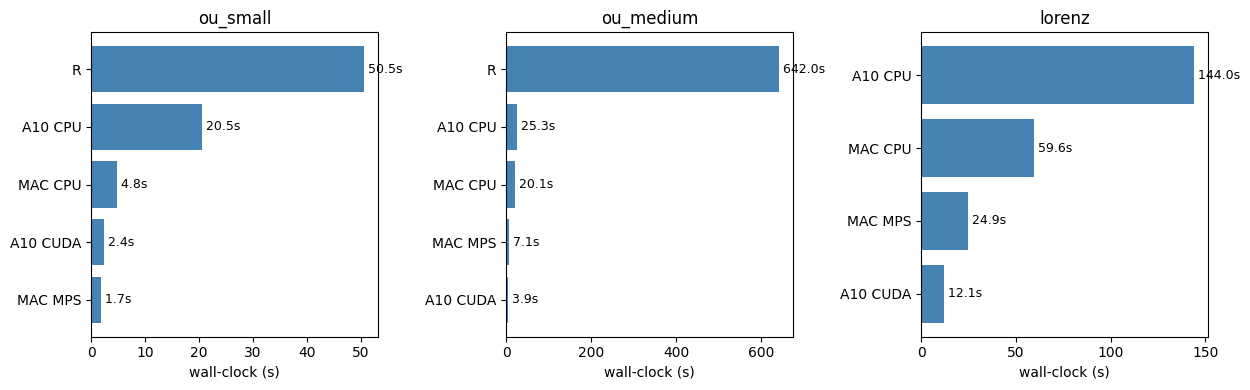

In [3]:
if df.empty:
    print('No benchmark data found yet — populate by running:')
    print('  uv run python scripts/run_device_benchmark.py --device cpu  --output bench_a10_cpu.json')
    print('  uv run python scripts/run_device_benchmark.py --device cuda --output bench_a10_cuda.json')
    print('  (and similar on Mac CPU / MPS)')
else:
    problems = list(df['problem'].unique())
    fig, axes = plt.subplots(1, len(problems), figsize=(4.2 * len(problems), 4),
                             squeeze=False)
    for ax, problem in zip(axes[0], problems):
        sub = df[df['problem'] == problem].sort_values('median_s')
        ax.barh(sub['label'], sub['median_s'], color='steelblue')
        ax.set(xlabel='wall-clock (s)', title=problem)
        for i, v in enumerate(sub['median_s']):
            ax.text(v, i, f' {v:.1f}s', va='center', fontsize=9)
    plt.tight_layout(); plt.show()


## Speedup table

Each Python device's wall-clock divided by the slowest CPU baseline on the
same problem. Higher = faster.

In [4]:
if df.empty:
    print('Not enough data to build a speedup table yet — need at least one CPU run.')
else:
    labels_str = ' '.join(df['label'].unique()).upper()
    if 'CPU' in labels_str:
        # Pick the slowest CPU run as baseline (typically the Mac CPU when both
        # are present; falls back to A10 CPU).
        cpu_mask = df['label'].str.contains('CPU', case=False)
        cpu_baseline = df[cpu_mask].groupby('problem')['median_s'].max()
        spd = df.copy()
        spd['speedup_vs_slowest_cpu'] = spd.apply(
            lambda r: cpu_baseline.get(r['problem'], np.nan) / r['median_s'], axis=1
        )
        pivot = spd.pivot(index='label', columns='problem', values='speedup_vs_slowest_cpu')
        display(pivot.round(2))
    else:
        print('No CPU run found — speedup table needs a CPU baseline.')


problem,lorenz,ou_medium,ou_small
label,,,
A10 CPU,1.00,1.00,1.00
A10 CUDA,11.87,6.49,8.71
MAC CPU,2.42,1.25,4.30
MAC MPS,5.78,3.55,11.77
R,NaN,0.04,0.41


## Final-L parity on `ou_small`

The published voila R README quotes `L = 36698.475` at convergence on this
exact realization. Every Python device should reproduce it within a documented
tolerance band — wide for MPS (FP32), tight for CPU and CUDA (FP64). This
table makes the agreement visible rather than asserted.

In [5]:
R_ANCHOR = 36698.475   # quoted in voila/README.md execution log

def _scalar_L(L):
    # ou_small final_L is a scalar; lorenz returns a per-component list.
    return float(L) if not isinstance(L, list) else float('nan')

ou_small = df[df['problem'] == 'ou_small'].copy()
if ou_small.empty:
    print('No ou_small data yet.')
else:
    ou_small['final_L'] = ou_small['final_L'].apply(_scalar_L)
    ou_small['delta_vs_R'] = ou_small['final_L'] - R_ANCHOR
    parity = ou_small[['label', 'dtype', 'final_L', 'delta_vs_R']].sort_values('label')
    display(parity.style.format({'final_L': '{:.4f}', 'delta_vs_R': '{:+.4f}'}))

    fp64_mask = parity['dtype'].str.contains('64', na=False)
    fp64_spread = float((parity.loc[fp64_mask, 'delta_vs_R']).abs().max()) if fp64_mask.any() else float('nan')
    fp32_spread = float((parity.loc[~fp64_mask, 'delta_vs_R']).abs().max()) if (~fp64_mask).any() else float('nan')
    print(f'\nMax |Δ| from R anchor across FP64 devices: {fp64_spread:.4f}  (expected < 0.5)')
    print(f'Max |Δ| from R anchor across FP32 devices: {fp32_spread:.4f}  (expected < 50)')


,label,dtype,final_L,delta_vs_R
0,A10 CPU,float64,36698.8988,+0.4238
3,A10 CUDA,float64,36698.9033,+0.4283
6,MAC CPU,float64,36698.9458,+0.4708
9,MAC MPS,float32,36682.4805,-15.9945
12,R,double,36698.4746,-0.0004



Max |Δ| from R anchor across FP64 devices: 0.4708  (expected < 0.5)
Max |Δ| from R anchor across FP32 devices: 15.9945  (expected < 50)


## What the numbers say

The interpretation below is regenerated from the loaded JSONs every time the
notebook runs, so it stays in sync with the data above.

In [6]:
from IPython.display import Markdown

if df.empty:
    display(Markdown('_(No benchmark data loaded — interpretation suppressed.)_'))
else:
    medians = df.set_index(['problem', 'label'])['median_s']
    labels = sorted(df['label'].unique())
    problems = list(df['problem'].unique())

    def t(problem, label):
        try:
            return float(medians.loc[(problem, label)])
        except KeyError:
            return None

    def fmt(v):
        return '—' if v is None else f'{v:.2f} s'

    def speedup(slow, fast):
        if slow is None or fast is None or fast == 0:
            return None
        return slow / fast

    bullets = []

    # Slowest baseline per problem (used as the headline 'how much faster')
    for problem in problems:
        per_label = {lab: t(problem, lab) for lab in labels}
        valid = {k: v for k, v in per_label.items() if v is not None}
        if not valid:
            continue
        slowest_label, slowest_t = max(valid.items(), key=lambda kv: kv[1])
        fastest_label, fastest_t = min(valid.items(), key=lambda kv: kv[1])
        bullets.append(
            f'- **`{problem}`**: slowest is **{slowest_label}** at **{fmt(slowest_t)}**, '
            f'fastest is **{fastest_label}** at **{fmt(fastest_t)}** '
            f'(**{speedup(slowest_t, fastest_t):.1f}×** spread).'
        )

    # If R reference is present, show "Python on this Mac vs R" as a separate point
    r_label = next((lab for lab in labels if lab.upper() == 'R' or lab.upper().startswith('R ')), None)
    mac_cpu_label = next((lab for lab in labels if 'MAC' in lab.upper() and 'CPU' in lab.upper()), None)
    if r_label and mac_cpu_label:
        bullets.append('')
        bullets.append('**Versus the original R implementation:**')
        for problem in ['ou_small', 'ou_medium']:
            r_t = t(problem, r_label)
            py_t = t(problem, mac_cpu_label)
            if r_t and py_t:
                bullets.append(
                    f'- `{problem}`: R takes **{fmt(r_t)}**, this Mac\'s CPU port takes '
                    f'**{fmt(py_t)}** — **{speedup(r_t, py_t):.1f}×** faster despite '
                    f'matching the same final ELBO.'
                )

    # GPU vs CPU asymmetry note — depends on whether multiple CPUs are present
    cpu_labels = [lab for lab in labels if 'CPU' in lab.upper() and 'R ' not in lab.upper()]
    if len(cpu_labels) > 1:
        bullets.append('')
        bullets.append(
            '**The "GPU vs CPU" speedup depends heavily on which CPU you compare against** — '
            f'see the speedup table above. ' +
            ', '.join(f'{lab} = {fmt(t("ou_small", lab))}' for lab in cpu_labels) +
            ' on `ou_small`.'
        )

    md_str = (
        '### Interpretation (auto-generated from current JSONs)\n\n' +
        '\n'.join(bullets) + '\n\n' +
        '_Re-run this cell after dropping new `bench_*.json` files to update._'
    )
    display(Markdown(md_str))


### Interpretation (auto-generated from current JSONs)

- **`ou_small`**: slowest is **R** at **50.51 s**, fastest is **MAC MPS** at **1.74 s** (**29.0×** spread).
- **`ou_medium`**: slowest is **R** at **642.05 s**, fastest is **A10 CUDA** at **3.90 s** (**164.8×** spread).
- **`lorenz`**: slowest is **A10 CPU** at **143.98 s**, fastest is **A10 CUDA** at **12.13 s** (**11.9×** spread).

**Versus the original R implementation:**
- `ou_small`: R takes **50.51 s**, this Mac's CPU port takes **4.76 s** — **10.6×** faster despite matching the same final ELBO.
- `ou_medium`: R takes **642.05 s**, this Mac's CPU port takes **20.15 s** — **31.9×** faster despite matching the same final ELBO.

**The "GPU vs CPU" speedup depends heavily on which CPU you compare against** — see the speedup table above. A10 CPU = 20.50 s, MAC CPU = 4.76 s on `ou_small`.

_Re-run this cell after dropping new `bench_*.json` files to update._

## Caveats and what to read next

- **Small / 1-D problems** (`ou_small`) are dominated by L-BFGS-B and Python
  overhead, not GP linear algebra; expect GPU and CPU to be close. The
  hyperparameter step is scipy-bound regardless of where the kernel work runs.
- **Medium / multivariate problems** (`ou_medium`, `lorenz`) are where GPU
  pays off — bigger Cholesky and matmul kernels amortize launch overhead.
- **MPS** runs at FP32 (Apple Silicon's Metal backend has no FP64 linalg).
  The ELBO drift band is documented; the recovered drift function itself is
  unaffected. See `tests/unit/test_devices.py` for the per-device tolerance
  table.
- The full validation suite — including drift-correlation checks against the
  ground truth on each device — lives in `tests/unit/test_devices.py` and
  `tests/regression/test_ou_parity.py`.
